In [1]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path
import datetime as dt

import pandas as pd
import pandas_datareader.data as pdr
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import talib as ta

In [2]:
sys.path.append("/home/jovyan/notebook")
from Modules.get_market_data import GetMarketData
get_market_data = GetMarketData(Path('/home/jovyan/data'))

### ゴールデンクロスとデッドクロスの見方

In [1]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2021, 10, 30)
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 6, 1)

### コニカミノルタ (4902.T)
df = get_market_data.get_data_from_yfinance("4902.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()

rdf = df[display_start_date:end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf["ma5"], color="blue", panel=0, width=0.7),
    # 25日間移動平均線
    mpf.make_addplot(rdf["ma25"], color="green", panel=0, width=0.7)
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(2,1), addplot=apd, returnfig=True)
l1, l2 = axes[0].lines
axes[0].legend([l1, l2], ["MA5", "MA25"])
fig.show()


NameError: name 'dt' is not defined

[*********************100%***********************]  1 of 1 completed

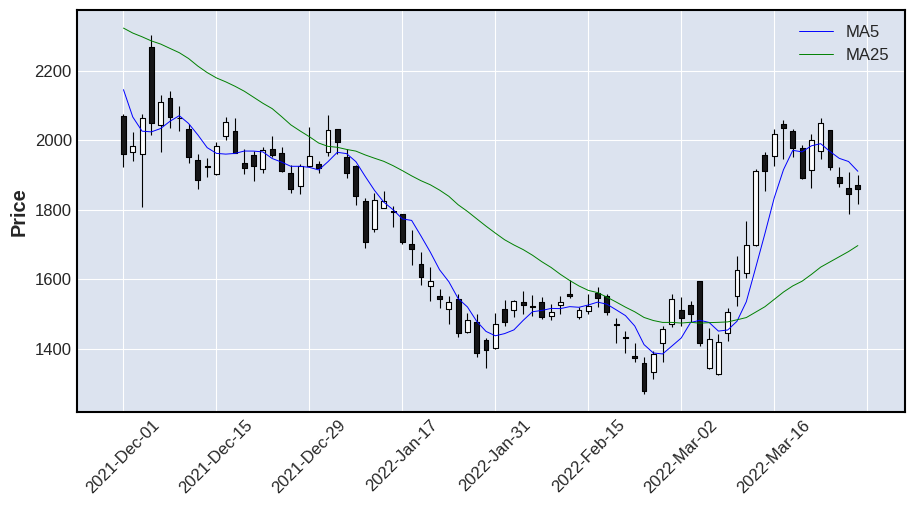

In [8]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 3, 31)
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 12, 1)

### ファーマフーズ  (2929.T)
df = get_market_data.get_data_from_yfinance("2929.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()

rdf = df[display_start_date:end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf["ma5"], color="blue", panel=0, width=0.7),
    # 25日間移動平均線
    mpf.make_addplot(rdf["ma25"], color="green", panel=0, width=0.7)
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(2,1), addplot=apd, returnfig=True)
l1, l2 = axes[0].lines
axes[0].legend([l1, l2], ["MA5", "MA25"])
fig.show()


### 5.3 ゴールデンクロスとデッドクロスの算出と表示

In [13]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 3, 31)
# データ取得開始日
#start_date = end_date - dt.timedelta(days=300)
start_date = dt.datetime(2016, 3, 1)
# チャート表示開始日
display_start_date = dt.datetime(2017, 3, 1)

### 日本製鉄  (5401.T)
df = get_market_data.get_data_from_yfinance("5401.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()

cross = df["ma5"] > df["ma25"]
df["cross"] = cross
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,ma5,ma25,cross
Date,,,,,,,,
2016-03-01,247.321747,250.158728,243.917373,248.771771,17529000,NaN,NaN,False
2016-03-02,263.965424,264.406720,255.139257,258.480584,26509500,NaN,NaN,False
2016-03-03,276.322083,278.906893,268.504624,268.630719,28824500,NaN,NaN,False
2016-03-04,278.528534,279.978558,269.134977,271.152394,25832500,NaN,NaN,False
2016-03-07,276.574188,280.419859,275.880700,276.574188,21670500,268.542395,NaN,False
...,...,...,...,...,...,...,...,...
2022-03-24,325.810822,326.749355,321.407015,322.417724,46874500,317.551862,303.722419,True
2022-03-25,329.709320,334.762890,326.388399,329.203954,55899000,321.724670,305.166294,True
2022-03-28,324.944550,331.802966,319.818781,329.925921,46420500,324.395844,306.532203,True


In [14]:
cross_shift = df["cross"].shift(1)

# ゴールデンクロスの発生日
temp_gc = (cross != cross_shift) & (cross == True)

# デッドクロスの発生日
temp_dc = (cross != cross_shift) & (cross == False)

In [16]:
# ゴールデンクロスの発生日であればMA5の値、それ以外はNaN
gc = [m if g == True else np.nan for g, m in zip(temp_gc, df["ma5"])]

# デッドクロスの発生日であればMA25の値、それ以外はNaN
dc = [m if d == True else np.nan for d, m in zip(temp_dc, df["ma25"])]

# データフレームのカラムとして保存
df["gc"], df["dc"] = gc, dc
df

Price,Close,High,Low,Open,Volume,ma5,ma25,cross,gc,dc
Date,,,,,,,,,,
2016-03-01,247.321747,250.158728,243.917373,248.771771,17529000,NaN,NaN,False,NaN,NaN
2016-03-02,263.965424,264.406720,255.139257,258.480584,26509500,NaN,NaN,False,NaN,NaN
2016-03-03,276.322083,278.906893,268.504624,268.630719,28824500,NaN,NaN,False,NaN,NaN
2016-03-04,278.528534,279.978558,269.134977,271.152394,25832500,NaN,NaN,False,NaN,NaN
2016-03-07,276.574188,280.419859,275.880700,276.574188,21670500,268.542395,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2022-03-24,325.810822,326.749355,321.407015,322.417724,46874500,317.551862,303.722419,True,NaN,NaN
2022-03-25,329.709320,334.762890,326.388399,329.203954,55899000,321.724670,305.166294,True,NaN,NaN
2022-03-28,324.944550,331.802966,319.818781,329.925921,46420500,324.395844,306.532203,True,NaN,NaN


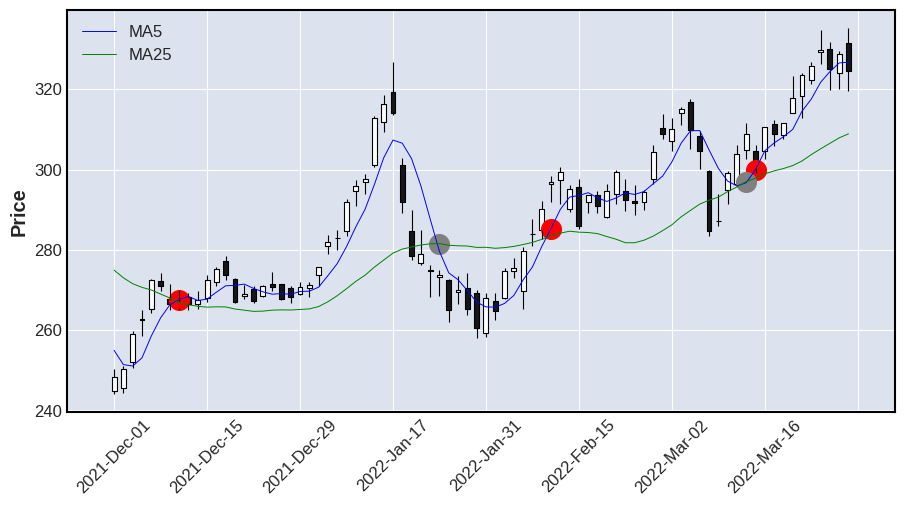

In [17]:
rdf = df[dt.datetime(2021, 12, 1):dt.datetime(2022, 3, 31)]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf["ma5"], color="blue", panel=0, width=0.7),
    # 25日間移動平均線
    mpf.make_addplot(rdf["ma25"], color="green", panel=0, width=0.7),
    mpf.make_addplot(rdf["gc"], type="scatter", markersize=200, marker="o", color="red", panel=0),
    mpf.make_addplot(rdf["dc"], type="scatter", markersize=200, marker="o", color="gray", panel=0)
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(2,1), addplot=apd, returnfig=True)
l1, l2 = axes[0].lines[:2]
axes[0].legend([l1, l2], ["MA5", "MA25"])
fig.show()

### 5.3 売買シグナルの検出

[*********************100%***********************]  1 of 1 completed


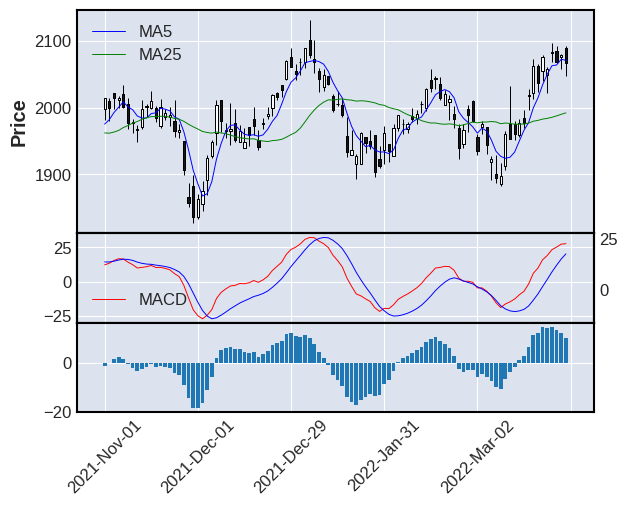

In [19]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 3, 31)
# データ取得開始日
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日
display_start_date = dt.datetime(2021, 11, 1)

### 積水ハウス  (1928.T)
df = get_market_data.get_data_from_yfinance("1928.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()

# MACD, シグナル, ヒストグラムを算出
macd, macdsignal, hist = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
df["macd"] = macd
df["macd_signal"] = macdsignal
df["hist"] = hist

# 2021.11.1から2023.3.31までのチャートを作成
rdf = df[display_start_date:end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf["ma5"], color="blue", panel=0, width=0.7),
    # 25日間移動平均線
    mpf.make_addplot(rdf["ma25"], color="green", panel=0, width=0.7),
    # MACD
    mpf.make_addplot(rdf["macd"], panel=1, width=0.7, color="red"),
    # シグナル
    mpf.make_addplot(rdf["macd_signal"], panel=1, width=0.7, color="blue"),
    # ヒストグラム
    mpf.make_addplot(rdf["hist"], panel=2, type="bar")
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(5,4), addplot=apd, returnfig=True)
axes[2].legend(["MACD", "Signal"])
fig.show()
axes[0].legend([l1, l2], ["MA5", "MA25"])

### ボリンジャーバンド、移動平均線、MACDからの考察

In [27]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 3, 31)
# データ取得開始日
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日
display_start_date = dt.datetime(2021, 11, 1)

### 積水ハウス  (1928.T)
df = get_market_data.get_data_from_yfinance("1928.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

# 5日間移動平均線と25日間移動平均線を算出
df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()

# ボリンジャーバンド±1σ、±2σ
df["upper1"], _, df["lower1"] = ta.BBANDS(close, timeperiod=25, nbdevup=1, nbdevdn=1, matype=ta.MA_Type.SMA)
df["upper2"], _, df["lower2"] = ta.BBANDS(close, timeperiod=25, nbdevup=2, nbdevdn=2, matype=ta.MA_Type.SMA)

cross = df["ma5"] > df["ma25"]
df["cross"] = cross

[*********************100%***********************]  1 of 1 completed


In [28]:
cross_shift = df["cross"].shift(1)

# ゴールデンクロスの発生日
temp_gc = (cross != cross_shift) & (cross == True)

# デッドクロスの発生日
temp_dc = (cross != cross_shift) & (cross == False)

# ゴールデンクロスの発生日であればMA5の値、それ以外はNaN
gc = [m if g == True else np.nan for g, m in zip(temp_gc, df["ma5"])]

# デッドクロスの発生日であればMA25の値、それ以外はNaN
dc = [m if d == True else np.nan for d, m in zip(temp_dc, df["ma25"])]

# データフレームのカラムとして保存
df["gc"], df["dc"] = gc, dc

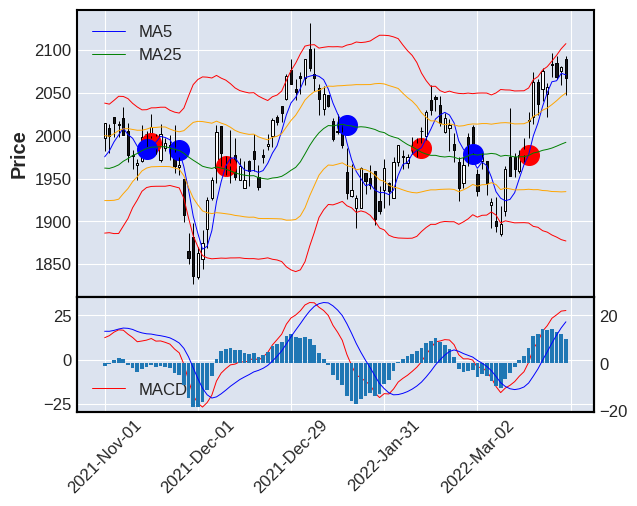

In [32]:


apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf["ma5"], color="blue", panel=0, width=0.7),
    # 25日間移動平均線
    mpf.make_addplot(rdf["ma25"], color="green", panel=0, width=0.7),
    # ゴールデンクロス
    mpf.make_addplot(rdf["gc"], type="scatter", markersize=200, marker="o", color="red", panel=0),
    # デッドクロス
    mpf.make_addplot(rdf["dc"], type="scatter", markersize=200, marker="o", color="blue", panel=0),
    # １σ
    mpf.make_addplot(rdf["upper1"], color="orange", panel=0, width=0.7),
    # -１σ
    mpf.make_addplot(rdf["lower1"], color="orange", panel=0, width=0.7),
    # ２σ
    mpf.make_addplot(rdf["upper2"], color="red", panel=0, width=0.7),
    # -２σ
    mpf.make_addplot(rdf["lower2"], color="red", panel=0, width=0.7),
    # MACD
    mpf.make_addplot(rdf["macd"], panel=1, width=0.7, color="red"),
    # シグナル
    mpf.make_addplot(rdf["macd_signal"], panel=1, width=0.7, color="blue"),
    # ヒストグラム
    mpf.make_addplot(rdf["hist"], panel=1, type="bar")
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(5,4), addplot=apd, returnfig=True)
axes[2].legend(["MACD", "Signal"])
fig.show()
axes[0].legend([l1, l2], ["MA5", "MA25"])